# STEP 1 — IMAGE-BASED PRODUCT IDENTIFICATION

This notebook demonstrates image-based supermarket product identification using the trained ResNet-50 model.

The final Stage 2 fine-tuned model is loaded from the saved checkpoint and used to classify individual supermarket product images into one of the 81 fine-grained product classes.

### Objectives

- Load the trained ResNet-50 model
- Load the 81 product class labels
- Load the saved Stage 2 checkpoint
- Apply the same preprocessing used during model evaluation
- Predict the product class from an input image
- Display the predicted class and confidence score
- Test the model on multiple supermarket product images

## STEP 2 — ENVIRONMENT AND LIBRARIES

The required Python libraries are imported for model loading, image preprocessing, prediction, and visualization.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)

Libraries imported successfully.
PyTorch version: 2.14.0+cpu


## STEP 3 — PROJECT PATHS

The project uses the saved Stage 2 ResNet-50 checkpoint and the GroceryStoreDataset metadata.

The checkpoint contains the trained model parameters required for inference.

In [2]:
# Project root
PROJECT_ROOT = os.path.abspath("..")

# Dataset paths
DATASET_ROOT = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "GroceryStoreDataset-master",
    "dataset"
)

# Correct Stage 2 model checkpoint path
CHECKPOINT_PATH = os.path.join(
    PROJECT_ROOT,
    "results",
    "checkpoints",
    "resnet50",
    "resnet50_stage2_best.pth"
)

# Class metadata
CLASSES_CSV = os.path.join(
    DATASET_ROOT,
    "classes.csv"
)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATASET_ROOT :", DATASET_ROOT)
print("CHECKPOINT   :", CHECKPOINT_PATH)
print("CLASSES CSV  :", CLASSES_CSV)

print("\nChecking required files...")

print("Checkpoint exists:", os.path.exists(CHECKPOINT_PATH))
print("classes.csv exists:", os.path.exists(CLASSES_CSV))

PROJECT_ROOT : c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification
DATASET_ROOT : c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset
CHECKPOINT   : c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\results\checkpoints\resnet50\resnet50_stage2_best.pth
CLASSES CSV  : c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\classes.csv

Checking required files...
Checkpoint exists: True
classes.csv exists: True


## STEP 4 — COMPUTATION DEVICE

The notebook automatically selects CUDA when a compatible GPU is available. Otherwise, inference is performed using the CPU.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU for inference.")

Device: cpu
Using CPU for inference.


## STEP 5 — LOAD PRODUCT CLASS LABELS

The GroceryStoreDataset contains 81 fine-grained product classes.

The class metadata is loaded from `classes.csv` so that the numerical output of the neural network can be converted into the corresponding product name.

In [4]:
classes_df = pd.read_csv(CLASSES_CSV)

print("Classes metadata shape:", classes_df.shape)
print("\nColumns:")
print(classes_df.columns.tolist())

display(classes_df.head())

Classes metadata shape: (81, 6)

Columns:
['Class Name (str)', 'Class ID (int)', 'Coarse Class Name (str)', 'Coarse Class ID (int)', 'Iconic Image Path (str)', 'Product Description Path (str)']


,Class Name (str),Class ID (int),Coarse Class Name (str),Coarse Class ID (int),Iconic Image Path (str),Product Description Path (str)
0,Golden-Delicious,0,Apple,0,/iconic-images-and-descriptions/Fruit/Apple/Go...,/iconic-images-and-descriptions/Fruit/Apple/Go...
1,Granny-Smith,1,Apple,0,/iconic-images-and-descriptions/Fruit/Apple/Gr...,/iconic-images-and-descriptions/Fruit/Apple/Gr...
2,Pink-Lady,2,Apple,0,/iconic-images-and-descriptions/Fruit/Apple/Pi...,/iconic-images-and-descriptions/Fruit/Apple/Pi...
3,Red-Delicious,3,Apple,0,/iconic-images-and-descriptions/Fruit/Apple/Re...,/iconic-images-and-descriptions/Fruit/Apple/Re...
4,Royal-Gala,4,Apple,0,/iconic-images-and-descriptions/Fruit/Apple/Ro...,/iconic-images-and-descriptions/Fruit/Apple/Ro...


## STEP 6 — BUILD THE PRODUCT CLASS MAPPING

The GroceryStoreDataset contains 81 fine-grained product classes.

The class names are mapped to their corresponding numerical class IDs using the `classes.csv` metadata file. The ordering is important because the ResNet-50 output index directly corresponds to the class ID.

In [5]:
# Build class ID -> class name mapping

class_names = (
    classes_df
    .sort_values("Class ID (int)")["Class Name (str)"]
    .tolist()
)

num_classes = len(class_names)

print("Number of classes:", num_classes)

print("\nFirst 10 classes:")
for class_id, class_name in enumerate(class_names[:10]):
    print(f"{class_id:2d} -> {class_name}")

print("\nLast 5 classes:")
for class_id in range(num_classes - 5, num_classes):
    print(f"{class_id:2d} -> {class_names[class_id]}")

Number of classes: 81

First 10 classes:
 0 -> Golden-Delicious
 1 -> Granny-Smith
 2 -> Pink-Lady
 3 -> Red-Delicious
 4 -> Royal-Gala
 5 -> Avocado
 6 -> Banana
 7 -> Kiwi
 8 -> Lemon
 9 -> Lime

Last 5 classes:
76 -> Red-Beet
77 -> Beef-Tomato
78 -> Regular-Tomato
79 -> Vine-Tomato
80 -> Zucchini


## STEP 7 — RECREATE THE RESNET-50 MODEL

The trained model is based on ResNet-50 with an ImageNet-pretrained backbone.

During training, the original final fully connected layer was replaced with a new classification layer containing 81 output neurons, corresponding to the 81 fine-grained supermarket product classes.

The same architecture must be recreated before loading the saved Stage 2 checkpoint.

In [6]:
# Recreate ResNet-50 architecture

model = models.resnet50(weights=None)

# Replace the final classification layer
model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

# Move model to selected device
model = model.to(device)

print("Model architecture created successfully.")
print("Model:", model.__class__.__name__)
print("Number of output classes:", model.fc.out_features)

Model architecture created successfully.
Model: ResNet
Number of output classes: 81


## STEP 8 — LOAD THE TRAINED STAGE 2 CHECKPOINT

The final Stage 2 ResNet-50 checkpoint is loaded from the project results directory.

This checkpoint contains the trained parameters from the Stage 2 fine-tuning process. No additional training is performed in this notebook.

In [7]:
# Load the trained Stage 2 checkpoint

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)

print("Checkpoint loaded successfully.")
print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nCheckpoint keys:")
    print(list(checkpoint.keys()))

Checkpoint loaded successfully.
Checkpoint type: <class 'dict'>

Checkpoint keys:
['model_state_dict', 'best_val_loss', 'best_val_accuracy', 'num_classes', 'image_size', 'model_name', 'trainable_blocks', 'layer4_learning_rate', 'fc_learning_rate', 'weight_decay']


## STEP 9 — LOAD AND VERIFY THE TRAINED MODEL

The saved Stage 2 checkpoint contains the trained ResNet-50 parameters along with the training configuration.

The `model_state_dict` is loaded into the recreated ResNet-50 architecture. The checkpoint metadata is also verified to ensure that the loaded model corresponds to the expected 81-class Stage 2 model.

In [8]:
# Verify checkpoint configuration

print("=" * 60)
print("CHECKPOINT CONFIGURATION")
print("=" * 60)

print("Model name:", checkpoint["model_name"])
print("Number of classes:", checkpoint["num_classes"])
print("Image size:", checkpoint["image_size"])
print("Trainable blocks:", checkpoint["trainable_blocks"])
print("Layer4 learning rate:", checkpoint["layer4_learning_rate"])
print("FC learning rate:", checkpoint["fc_learning_rate"])
print("Weight decay:", checkpoint["weight_decay"])

print("\nSaved validation accuracy:",
      f"{checkpoint['best_val_accuracy'] * 100:.2f}%")

print("Saved validation loss:",
      f"{checkpoint['best_val_loss']:.6f}")

CHECKPOINT CONFIGURATION
Model name: ResNet-50
Number of classes: 81
Image size: 224
Trainable blocks: ['layer4', 'fc']
Layer4 learning rate: 1e-05
FC learning rate: 0.0001
Weight decay: 0.0001

Saved validation accuracy: 72.30%
Saved validation loss: 0.933781


In [9]:
# Validate the checkpoint configuration

assert checkpoint["num_classes"] == num_classes
assert checkpoint["model_name"] == "ResNet-50"
assert checkpoint["image_size"] == 224

print("Checkpoint configuration verification PASSED.")

Checkpoint configuration verification PASSED.


### Loading the trained model parameters

The trained parameters stored in `model_state_dict` are loaded into the ResNet-50 architecture created in the previous step.

In [10]:
# Load trained parameters

model.load_state_dict(checkpoint["model_state_dict"])

# Set model to evaluation mode
model.eval()

print("Trained model weights loaded successfully.")
print("Model is now ready for inference.")

Trained model weights loaded successfully.
Model is now ready for inference.


## STEP 10 — INFERENCE PREPROCESSING

Input images are resized to 224 × 224 pixels and normalized using the ImageNet mean and standard deviation.

The inference preprocessing follows the validation/test preprocessing used during model evaluation. Random training augmentations are not applied during inference.

In [11]:
# Inference preprocessing
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Inference preprocessing pipeline created.")

Inference preprocessing pipeline created.


## STEP 11 — SELECT A TEST IMAGE

A sample image is selected from the GroceryStoreDataset test set.

Using a test-set image allows the trained model to be evaluated on an image that was not used during training. The corresponding ground-truth class is obtained from the dataset test annotations.

In [12]:
# Test annotation file
TEST_LABELS_PATH = os.path.join(
    DATASET_ROOT,
    "test.txt"
)

print("Test labels file:", TEST_LABELS_PATH)
print("File exists:", os.path.exists(TEST_LABELS_PATH))

Test labels file: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\test.txt
File exists: True


In [13]:
# Read the test annotation file

test_df = pd.read_csv(
    TEST_LABELS_PATH,
    sep=" ",
    header=None,
    names=["image_path", "fine_class_id", "coarse_class_id"]
)

print("Number of test images:", len(test_df))
print("\nFirst 5 test samples:")
display(test_df.head())

Number of test images: 2485

First 5 test samples:


,image_path,fine_class_id,coarse_class_id
0,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,"0,",0
1,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,"0,",0
2,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,"0,",0
3,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,"0,",0
4,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,"0,",0


In [16]:
# Read the test annotation file
# The dataset uses comma-separated values.

test_df = pd.read_csv(
    TEST_LABELS_PATH,
    header=None,
    names=["image_path", "fine_class_id", "coarse_class_id"],
    skipinitialspace=True
)

# Remove possible trailing commas/whitespace from annotation fields
test_df["fine_class_id"] = (
    test_df["fine_class_id"]
    .astype(str)
    .str.strip()
    .str.rstrip(",")
    .astype(int)
)

test_df["coarse_class_id"] = (
    test_df["coarse_class_id"]
    .astype(str)
    .str.strip()
    .str.rstrip(",")
    .astype(int)
)

print("Number of test images:", len(test_df))

print("\nFirst 5 test samples:")
display(test_df.head())

Number of test images: 2485

First 5 test samples:


,image_path,fine_class_id,coarse_class_id
0,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,0,0
1,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,0,0
2,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,0,0
3,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,0,0
4,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,0,0


In [17]:
# Select the first test image

sample_index = 0

relative_image_path = test_df.iloc[sample_index]["image_path"]
true_class_id = int(test_df.iloc[sample_index]["fine_class_id"])

image_path = os.path.join(
    DATASET_ROOT,
    relative_image_path
)

true_class_name = class_names[true_class_id]

print("Image path:", image_path)
print("Ground-truth class ID:", true_class_id)
print("Ground-truth class:", true_class_name)
print("Image exists:", os.path.exists(image_path))

Image path: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\test/Fruit/Apple/Golden-Delicious/Golden-Delicious_001.jpg
Ground-truth class ID: 0
Ground-truth class: Golden-Delicious
Image exists: True


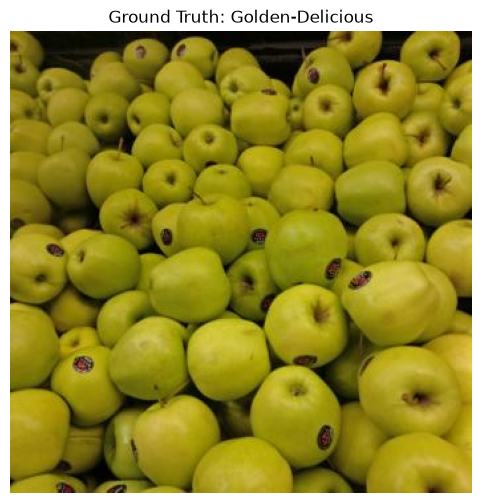

In [18]:
# Display the selected test image

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(f"Ground Truth: {true_class_name}")
plt.show()

## STEP 12 — MAKE A PRODUCT PREDICTION

The selected test image is passed through the trained ResNet-50 model.

The model produces prediction scores for all 81 product classes. A softmax function converts these scores into probabilities, and the class with the highest probability is selected as the predicted product.

In [19]:
# Prepare image for model inference

input_tensor = inference_transform(image)

# Add batch dimension
input_batch = input_tensor.unsqueeze(0).to(device)

print("Original image size:", image.size)
print("Input tensor shape:", input_batch.shape)

Original image size: (348, 348)
Input tensor shape: torch.Size([1, 3, 224, 224])


In [20]:
# Run model inference

with torch.no_grad():
    outputs = model(input_batch)

# Convert model outputs to probabilities
probabilities = torch.softmax(outputs, dim=1)

# Get predicted class and confidence
predicted_class_id = torch.argmax(probabilities, dim=1).item()
predicted_class_name = class_names[predicted_class_id]
confidence = probabilities[0, predicted_class_id].item()

print("=" * 60)
print("MODEL PREDICTION")
print("=" * 60)
print("Predicted class ID:", predicted_class_id)
print("Predicted product:", predicted_class_name)
print(f"Confidence: {confidence * 100:.2f}%")
print("=" * 60)

MODEL PREDICTION
Predicted class ID: 1
Predicted product: Granny-Smith
Confidence: 86.99%


## STEP 13 — VISUALIZE THE PREDICTION RESULT

The input image is displayed together with its ground-truth class, predicted product class, and prediction confidence.

This provides a clear visual demonstration of the model's image-based product identification capability.

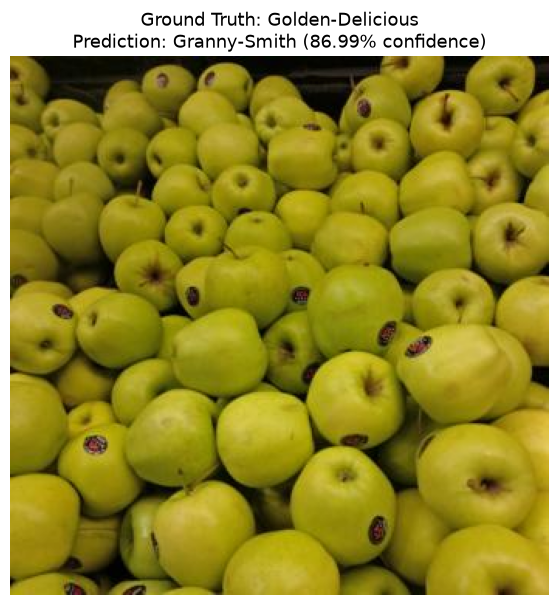

PREDICTION RESULT
Ground Truth : Golden-Delicious
Prediction   : Granny-Smith
Confidence   : 86.99%
Correct      : False


In [21]:
# Display ground truth and model prediction

plt.figure(figsize=(8, 7))

plt.imshow(image)
plt.axis("off")

plt.title(
    f"Ground Truth: {true_class_name}\n"
    f"Prediction: {predicted_class_name} "
    f"({confidence * 100:.2f}% confidence)",
    fontsize=13
)

plt.show()

print("=" * 60)
print("PREDICTION RESULT")
print("=" * 60)
print(f"Ground Truth : {true_class_name}")
print(f"Prediction   : {predicted_class_name}")
print(f"Confidence   : {confidence * 100:.2f}%")
print(f"Correct      : {predicted_class_id == true_class_id}")
print("=" * 60)

## STEP 14 — MULTIPLE IMAGE PREDICTION

Multiple images from the unseen test set are used to demonstrate the behavior of the trained model across different supermarket product categories.

For each image, the ground-truth class, predicted class, confidence score, and prediction correctness are recorded.

In [22]:
# Select multiple test images

num_samples = 12

sample_indices = np.linspace(
    0,
    len(test_df) - 1,
    num_samples,
    dtype=int
)

print("Selected test image indices:")
print(sample_indices)

Selected test image indices:
[   0  225  451  677  903 1129 1354 1580 1806 2032 2258 2484]


### Running predictions on multiple test images

The trained ResNet-50 model is applied to 12 representative images selected from the test set.

For each image, the system records:

- Ground-truth product
- Predicted product
- Prediction confidence
- Whether the prediction is correct

These results provide a small qualitative demonstration of the trained model's product identification performance.

In [23]:
# Run predictions on the selected test images

prediction_results = []

for sample_index in sample_indices:

    # Get image information
    relative_image_path = test_df.iloc[sample_index]["image_path"]
    true_class_id = int(test_df.iloc[sample_index]["fine_class_id"])

    image_path = os.path.join(
        DATASET_ROOT,
        relative_image_path
    )

    # Load image
    test_image = Image.open(image_path).convert("RGB")

    # Preprocess
    input_tensor = inference_transform(test_image)
    input_batch = input_tensor.unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        outputs = model(input_batch)
        probabilities = torch.softmax(outputs, dim=1)

    predicted_class_id = torch.argmax(
        probabilities,
        dim=1
    ).item()

    predicted_class_name = class_names[predicted_class_id]
    true_class_name = class_names[true_class_id]

    confidence = probabilities[
        0,
        predicted_class_id
    ].item()

    correct = predicted_class_id == true_class_id

    prediction_results.append({
        "Index": sample_index,
        "Ground Truth": true_class_name,
        "Prediction": predicted_class_name,
        "Confidence (%)": round(confidence * 100, 2),
        "Correct": correct
    })

# Convert results to DataFrame
prediction_results_df = pd.DataFrame(prediction_results)

print("=" * 80)
print("MULTIPLE IMAGE PREDICTION RESULTS")
print("=" * 80)

display(prediction_results_df)

MULTIPLE IMAGE PREDICTION RESULTS


,Index,Ground Truth,Prediction,Confidence (%),Correct
0,0,Golden-Delicious,Granny-Smith,86.99,False
1,225,Royal-Gala,Pink-Lady,76.28,False
2,451,Lime,Green-Bell-Pepper,52.44,False
3,677,Nectarine,Nectarine,84.40,True
4,903,Conference,Conference,80.22,True
5,1129,Bravo-Apple-Juice,Bravo-Apple-Juice,86.22,True
6,1354,Arla-Ecological-Medium-Fat-Milk,Arla-Ecological-Medium-Fat-Milk,71.97,True
7,1580,Arla-Ecological-Sour-Cream,Arla-Ecological-Sour-Cream,84.44,True
8,1806,Arla-Natural-Yoghurt,Arla-Natural-Yoghurt,70.15,True
9,2032,Garlic,Garlic,96.47,True


### Visual demonstration of predictions

The selected test images are displayed together with their ground-truth labels and model predictions. This allows qualitative inspection of correct classifications and visually similar misclassifications.

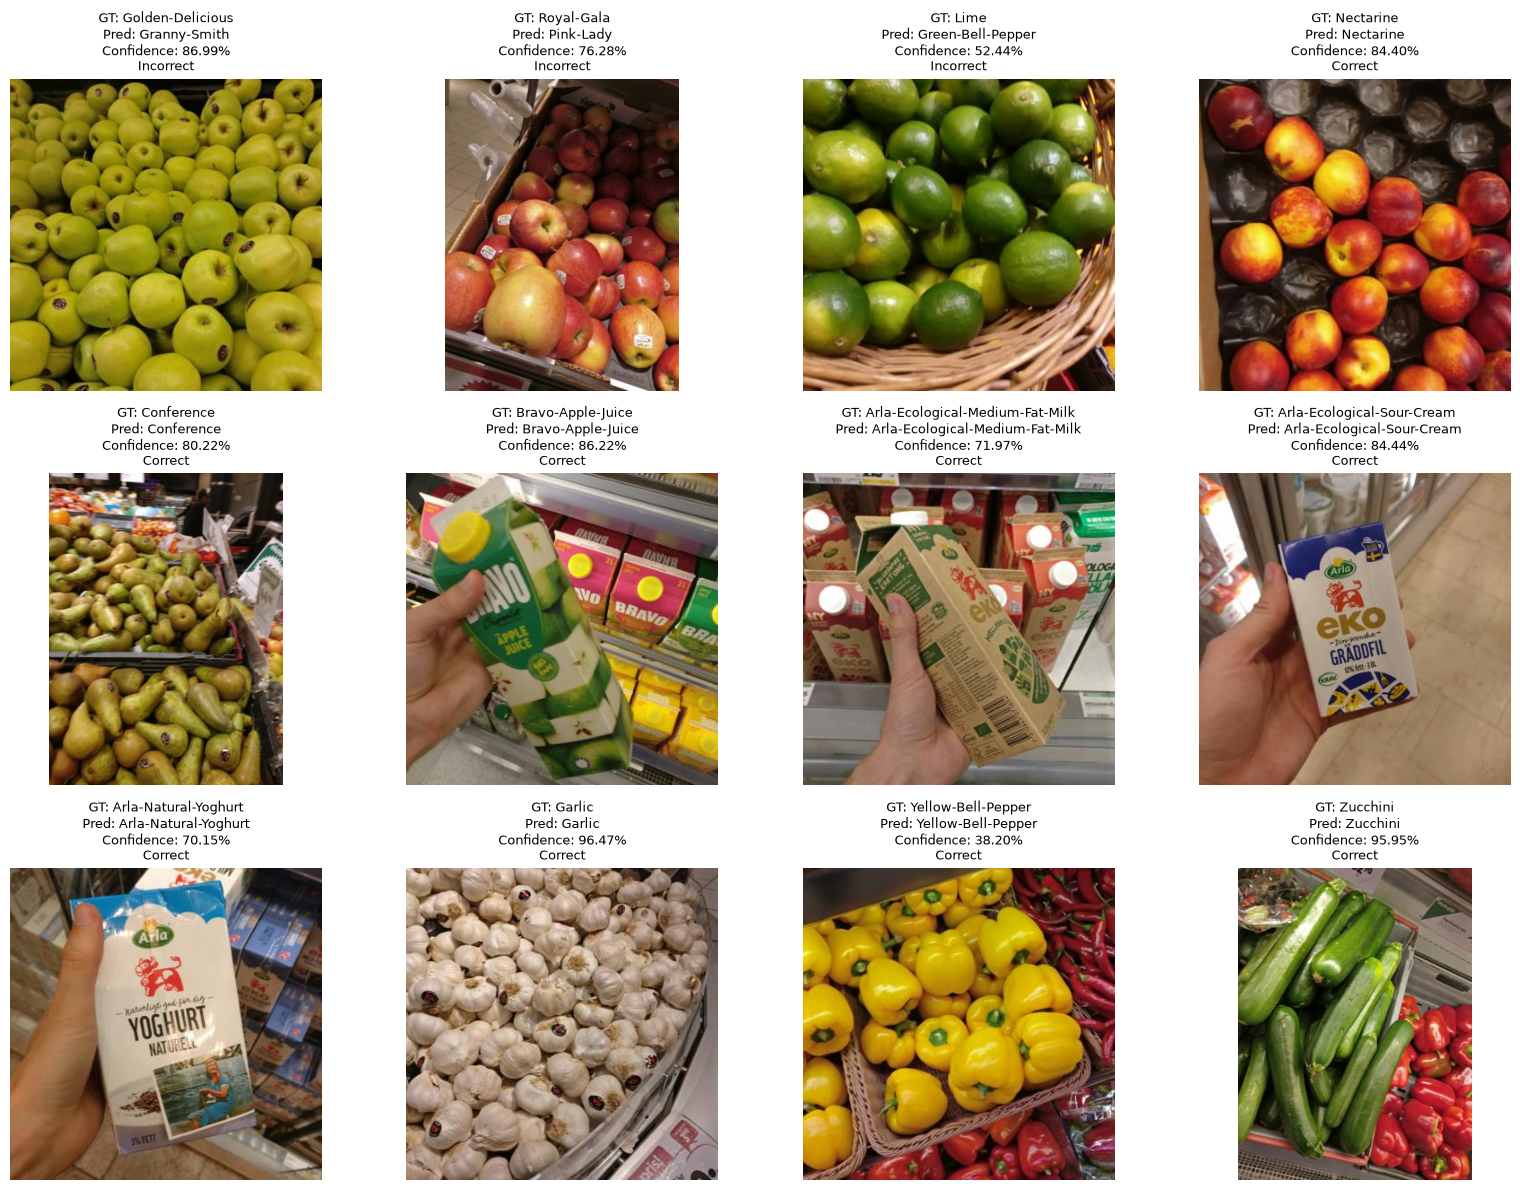

In [24]:
# Visualize multiple prediction results

fig, axes = plt.subplots(
    3,
    4,
    figsize=(16, 12)
)

for ax, (_, result) in zip(
    axes.ravel(),
    prediction_results_df.iterrows()
):

    sample_index = int(result["Index"])

    relative_image_path = test_df.iloc[sample_index]["image_path"]

    image_path = os.path.join(
        DATASET_ROOT,
        relative_image_path
    )

    display_image = Image.open(
        image_path
    ).convert("RGB")

    ax.imshow(display_image)
    ax.axis("off")

    correct_text = "Correct" if result["Correct"] else "Incorrect"

    ax.set_title(
        f"GT: {result['Ground Truth']}\n"
        f"Pred: {result['Prediction']}\n"
        f"Confidence: {result['Confidence (%)']:.2f}%\n"
        f"{correct_text}",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## STEP 15 — TOP-5 PREDICTION ANALYSIS

In addition to the highest-probability prediction, the five classes with the highest prediction probabilities are examined.

Top-5 predictions provide additional insight into model behavior, particularly for visually similar products where the correct class may not be the highest-probability prediction but may still appear among the top candidate classes.

In [25]:
# Function to obtain Top-5 predictions for an image

def get_top5_predictions(image_path):
    """
    Load an image and return the five highest-probability
    product predictions from the trained ResNet-50 model.
    """

    input_image = Image.open(image_path).convert("RGB")

    input_tensor = inference_transform(input_image)
    input_batch = input_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_batch)
        probabilities = torch.softmax(outputs, dim=1)

    top5_probabilities, top5_indices = torch.topk(
        probabilities,
        k=5,
        dim=1
    )

    results = []

    for probability, class_id in zip(
        top5_probabilities[0],
        top5_indices[0]
    ):
        class_id = class_id.item()
        probability = probability.item()

        results.append({
            "Class ID": class_id,
            "Product": class_names[class_id],
            "Probability (%)": round(probability * 100, 2)
        })

    return results

### Top-5 predictions for the sample image

The Top-5 probability distribution is displayed for the first test image used in the demonstration.

In [27]:
# Get Top-5 predictions for the FIRST demonstration image

first_sample_index = int(sample_indices[0])

first_relative_path = test_df.iloc[first_sample_index]["image_path"]

first_image_path = os.path.join(
    DATASET_ROOT,
    first_relative_path
)

first_true_class_id = int(
    test_df.iloc[first_sample_index]["fine_class_id"]
)

first_true_class_name = class_names[first_true_class_id]

# Get Top-5 predictions
top5_results = get_top5_predictions(first_image_path)

top5_df = pd.DataFrame(top5_results)

print("=" * 60)
print("TOP-5 PREDICTIONS — FIRST TEST IMAGE")
print("=" * 60)

print("Ground Truth:", first_true_class_name)
print("\nTop-5 Model Predictions:")

display(top5_df)

TOP-5 PREDICTIONS — FIRST TEST IMAGE
Ground Truth: Golden-Delicious

Top-5 Model Predictions:


,Class ID,Product,Probability (%)
0,1,Granny-Smith,86.99
1,0,Golden-Delicious,12.83
2,20,Anjou,0.14
3,2,Pink-Lady,0.01
4,8,Lemon,0.01


## STEP 16 — TOP-1 AND TOP-5 ACCURACY

Top-1 accuracy measures whether the correct product class is the model's highest-probability prediction.

Top-5 accuracy measures whether the correct product class appears anywhere among the five highest-probability predictions.

Both metrics are calculated for the 12 demonstration images.

In [28]:
# Calculate Top-1 and Top-5 accuracy for the 12 demonstration images

top1_correct = 0
top5_correct = 0

top5_summary = []

for sample_index in sample_indices:

    relative_image_path = test_df.iloc[sample_index]["image_path"]

    image_path_current = os.path.join(
        DATASET_ROOT,
        relative_image_path
    )

    true_class_id = int(
        test_df.iloc[sample_index]["fine_class_id"]
    )

    true_class_name = class_names[true_class_id]

    # Load and preprocess image
    input_image = Image.open(
        image_path_current
    ).convert("RGB")

    input_tensor = inference_transform(input_image)
    input_batch = input_tensor.unsqueeze(0).to(device)

    # Model prediction
    with torch.no_grad():
        outputs = model(input_batch)
        probabilities = torch.softmax(outputs, dim=1)

    # Top-5
    top5_probabilities, top5_indices = torch.topk(
        probabilities,
        k=5,
        dim=1
    )

    top5_ids = top5_indices[0].cpu().tolist()
    top5_probs = top5_probabilities[0].cpu().tolist()

    predicted_class_id = top5_ids[0]
    predicted_class_name = class_names[predicted_class_id]

    confidence = top5_probs[0] * 100

    is_top1_correct = (
        predicted_class_id == true_class_id
    )

    is_top5_correct = (
        true_class_id in top5_ids
    )

    if is_top1_correct:
        top1_correct += 1

    if is_top5_correct:
        top5_correct += 1

    top5_summary.append({
        "Index": sample_index,
        "Ground Truth": true_class_name,
        "Top-1 Prediction": predicted_class_name,
        "Top-1 Confidence (%)": round(confidence, 2),
        "Top-1 Correct": is_top1_correct,
        "Top-5 Correct": is_top5_correct,
        "Top-5 Predictions": ", ".join(
            class_names[class_id]
            for class_id in top5_ids
        )
    })

top5_summary_df = pd.DataFrame(top5_summary)

top1_accuracy = (
    top1_correct / len(sample_indices)
) * 100

top5_accuracy = (
    top5_correct / len(sample_indices)
) * 100

print("=" * 80)
print("TOP-1 VS TOP-5 DEMONSTRATION RESULTS")
print("=" * 80)

print(f"Number of images: {len(sample_indices)}")
print(f"Top-1 correct:    {top1_correct}/{len(sample_indices)}")
print(f"Top-1 accuracy:   {top1_accuracy:.2f}%")
print()
print(f"Top-5 correct:    {top5_correct}/{len(sample_indices)}")
print(f"Top-5 accuracy:   {top5_accuracy:.2f}%")
print("=" * 80)

display(top5_summary_df)

TOP-1 VS TOP-5 DEMONSTRATION RESULTS
Number of images: 12
Top-1 correct:    9/12
Top-1 accuracy:   75.00%

Top-5 correct:    12/12
Top-5 accuracy:   100.00%


,Index,Ground Truth,Top-1 Prediction,Top-1 Confidence (%),Top-1 Correct,Top-5 Correct,Top-5 Predictions
0,0,Golden-Delicious,Granny-Smith,86.99,False,True,"Granny-Smith, Golden-Delicious, Anjou, Pink-La..."
1,225,Royal-Gala,Pink-Lady,76.28,False,True,"Pink-Lady, Red-Delicious, Royal-Gala, Red-Grap..."
2,451,Lime,Green-Bell-Pepper,52.44,False,True,"Green-Bell-Pepper, Papaya, Lime, Zucchini, Mango"
3,677,Nectarine,Nectarine,84.40,True,True,"Nectarine, Peach, Royal-Gala, Red-Delicious, P..."
4,903,Conference,Conference,80.22,True,True,"Conference, Banana, Granny-Smith, Kaiser, Lemon"
5,1129,Bravo-Apple-Juice,Bravo-Apple-Juice,86.22,True,True,"Bravo-Apple-Juice, Bravo-Orange-Juice, Arla-La..."
6,1354,Arla-Ecological-Medium-Fat-Milk,Arla-Ecological-Medium-Fat-Milk,71.97,True,True,"Arla-Ecological-Medium-Fat-Milk, Garant-Ecolog..."
7,1580,Arla-Ecological-Sour-Cream,Arla-Ecological-Sour-Cream,84.44,True,True,"Arla-Ecological-Sour-Cream, Arla-Sour-Cream, Y..."
8,1806,Arla-Natural-Yoghurt,Arla-Natural-Yoghurt,70.15,True,True,"Arla-Natural-Yoghurt, Arla-Mild-Vanilla-Yoghur..."
9,2032,Garlic,Garlic,96.47,True,True,"Garlic, Golden-Delicious, Lemon, Cantaloupe, B..."


## STEP 17 — SAVE IMAGE PREDICTION RESULTS

The multiple-image prediction results are saved for reproducibility and documentation.

The results include the ground-truth class, Top-1 prediction, confidence, Top-1 correctness, Top-5 correctness, and Top-5 candidate classes.

In [30]:
# Create demonstration results directory

DEMO_RESULTS_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    "image_prediction"
)

os.makedirs(
    DEMO_RESULTS_DIR,
    exist_ok=True
)

print("Results directory:")
print(DEMO_RESULTS_DIR)
print("Directory exists:", os.path.exists(DEMO_RESULTS_DIR))

Results directory:
c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\results\image_prediction
Directory exists: True


In [31]:
# Save prediction results as CSV

csv_path = os.path.join(
    DEMO_RESULTS_DIR,
    "multiple_image_prediction_results.csv"
)

top5_summary_df.to_csv(
    csv_path,
    index=False
)

print("Prediction results saved:")
print(csv_path)

Prediction results saved:
c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\results\image_prediction\multiple_image_prediction_results.csv


In [32]:
# Save demonstration metrics

demo_metrics = {
    "model": "ResNet-50",
    "checkpoint": "resnet50_stage2_best.pth",
    "num_test_images": len(sample_indices),
    "top1_correct": int(top1_correct),
    "top1_accuracy_percent": round(top1_accuracy, 2),
    "top5_correct": int(top5_correct),
    "top5_accuracy_percent": round(top5_accuracy, 2),
    "official_full_test_accuracy_percent": 73.72
}

json_path = os.path.join(
    DEMO_RESULTS_DIR,
    "image_prediction_summary.json"
)

with open(json_path, "w") as f:
    json.dump(
        demo_metrics,
        f,
        indent=4
    )

print("Summary saved:")
print(json_path)

print("\nDEMONSTRATION SUMMARY")
print("=" * 50)
print(f"Images tested:       {len(sample_indices)}")
print(f"Top-1 accuracy:      {top1_accuracy:.2f}%")
print(f"Top-5 accuracy:      {top5_accuracy:.2f}%")
print(f"Official test:       73.72%")
print("=" * 50)

Summary saved:
c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\results\image_prediction\image_prediction_summary.json

DEMONSTRATION SUMMARY
Images tested:       12
Top-1 accuracy:      75.00%
Top-5 accuracy:      100.00%
Official test:       73.72%
